# Data Understanding, Profiling & Data Quality

## Objective

This notebook explores the raw Olist datasets to understand their structure, assess data quality, and identify potential issues before any transformations are applied.

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Load Datasets

In [22]:
RAW_DATA_PATH = Path("../data/raw")

datasets = {
    "customers": pd.read_csv(RAW_DATA_PATH / "olist_customers_dataset.csv"),
    "geolocation": pd.read_csv(RAW_DATA_PATH / "olist_geolocation_dataset.csv"),
    "order_items": pd.read_csv(RAW_DATA_PATH / "olist_order_items_dataset.csv"),
    "order_payments": pd.read_csv(RAW_DATA_PATH / "olist_order_payments_dataset.csv"),
    "order_reviews": pd.read_csv(RAW_DATA_PATH / "olist_order_reviews_dataset.csv"),
    "orders": pd.read_csv(RAW_DATA_PATH / "olist_orders_dataset.csv"),
    "products": pd.read_csv(RAW_DATA_PATH / "olist_products_dataset.csv"),
    "sellers": pd.read_csv(RAW_DATA_PATH / "olist_sellers_dataset.csv"),
    "category_translation": pd.read_csv(RAW_DATA_PATH / "product_category_name_translation.csv")
}

In [23]:
overview = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    }
    for name, df in datasets.items()
])

overview

,Dataset,Rows,Columns,Memory (MB)
0,customers,99441,5,26.59
1,geolocation,1000163,5,129.38
2,order_items,112650,7,35.99
3,order_payments,103886,5,16.23
4,order_reviews,99224,7,39.12
5,orders,99441,8,52.94
6,products,32951,9,6.30
7,sellers,3095,4,0.59
8,category_translation,71,2,0.01


In [24]:
for name, df in datasets.items():

    print("=" * 100)
    print(name.upper())

    display(df.dtypes.to_frame("Data Type"))

CUSTOMERS


,Data Type
customer_id,str
customer_unique_id,str
customer_zip_code_prefix,int64
customer_city,str
customer_state,str


GEOLOCATION


,Data Type
geolocation_zip_code_prefix,int64
geolocation_lat,float64
geolocation_lng,float64
geolocation_city,str
geolocation_state,str


ORDER_ITEMS


...

,Data Type
product_id,str
product_category_name,str
product_name_lenght,float64
product_description_lenght,float64
product_photos_qty,float64
product_weight_g,float64
product_length_cm,float64
product_height_cm,float64
product_width_cm,float64


SELLERS


,Data Type
seller_id,str
seller_zip_code_prefix,int64
seller_city,str
seller_state,str


CATEGORY_TRANSLATION


,Data Type
product_category_name,str
product_category_name_english,str


# Primary Key

In [25]:
primary_keys = {
    "customers": ["customer_id"],
    "geolocation": None,
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "category_translation": ["product_category_name"],
}

In [26]:
pk_results = []

for table, keys in primary_keys.items():

    if keys is None:

        pk_results.append({
            "Table": table,
            "Primary Key": "N/A",
            "Passed": "N/A",
            "Duplicate Keys": np.nan
        })

        continue

    duplicates = datasets[table].duplicated(subset=keys).sum()

    pk_results.append({
        "Table": table,
        "Primary Key": ", ".join(keys),
        "Passed": duplicates == 0,
        "Duplicate Keys": duplicates
    })

pk_results = pd.DataFrame(pk_results)

pk_results

,Table,Primary Key,Passed,Duplicate Keys
0,customers,customer_id,True,0.0
1,geolocation,N/A,N/A,NaN
2,order_items,"order_id, order_item_id",True,0.0
3,order_payments,"order_id, payment_sequential",True,0.0
4,order_reviews,review_id,False,814.0
5,orders,order_id,True,0.0
6,products,product_id,True,0.0
7,sellers,seller_id,True,0.0
8,category_translation,product_category_name,True,0.0


# Foreign Key

In [27]:
relationships = [

    ("orders", "customer_id",
     "customers", "customer_id"),

    ("order_items", "order_id",
     "orders", "order_id"),

    ("order_items", "product_id",
     "products", "product_id"),

    ("order_items", "seller_id",
     "sellers", "seller_id"),

    ("order_payments", "order_id",
     "orders", "order_id"),

    ("order_reviews", "order_id",
     "orders", "order_id"),

]

In [28]:
fk_results = []

for child_table, child_key, parent_table, parent_key in relationships:

    child = datasets[child_table][child_key]

    parent = datasets[parent_table][parent_key]

    orphan_rows = (~child.isin(parent)).sum()

    fk_results.append({

        "Relationship":
            f"{child_table}.{child_key} → {parent_table}.{parent_key}",

        "Passed":
            orphan_rows == 0,

        "Orphan Rows":
            orphan_rows

    })

fk_results = pd.DataFrame(fk_results)

fk_results

,Relationship,Passed,Orphan Rows
0,orders.customer_id → customers.customer_id,True,0
1,order_items.order_id → orders.order_id,True,0
2,order_items.product_id → products.product_id,True,0
3,order_items.seller_id → sellers.seller_id,True,0
4,order_payments.order_id → orders.order_id,True,0
5,order_reviews.order_id → orders.order_id,True,0


In [29]:
print(f"Datasets Loaded : {len(datasets)}")

print(f"PK Checks       : {len(pk_results)}")

print(f"FK Checks       : {len(fk_results)}")

Datasets Loaded : 9
PK Checks       : 9
FK Checks       : 6


# Missing Value

In [30]:
missing_by_dataset = pd.DataFrame([
    {
        "Dataset": name,
        "Missing Values": df.isna().sum().sum(),
        "Missing (%)": round(df.isna().sum().sum() / df.size * 100, 2)
    }
    for name, df in datasets.items()
]).sort_values("Missing (%)", ascending=False)

missing_by_dataset

,Dataset,Missing Values,Missing (%)
4,order_reviews,145903,21.01
6,products,2448,0.83
5,orders,4908,0.62
0,customers,0,0.00
1,geolocation,0,0.00
3,order_payments,0,0.00
2,order_items,0,0.00
7,sellers,0,0.00
8,category_translation,0,0.00


In [31]:
missing_by_column = []

for name, df in datasets.items():

    missing = df.isna().sum()

    missing = missing[missing > 0]

    for column, value in missing.items():

        missing_by_column.append({

            "Dataset": name,

            "Column": column,

            "Missing Values": value,

            "Missing (%)": round(value / len(df) * 100, 2)

        })

missing_by_column = (
    pd.DataFrame(missing_by_column)
    .sort_values(
        ["Missing (%)", "Dataset"],
        ascending=[False, True]
    )
)

missing_by_column

,Dataset,Column,Missing Values,Missing (%)
0,order_reviews,review_comment_title,87656,88.34
1,order_reviews,review_comment_message,58247,58.70
4,orders,order_delivered_customer_date,2965,2.98
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
3,orders,order_delivered_carrier_date,1783,1.79
2,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


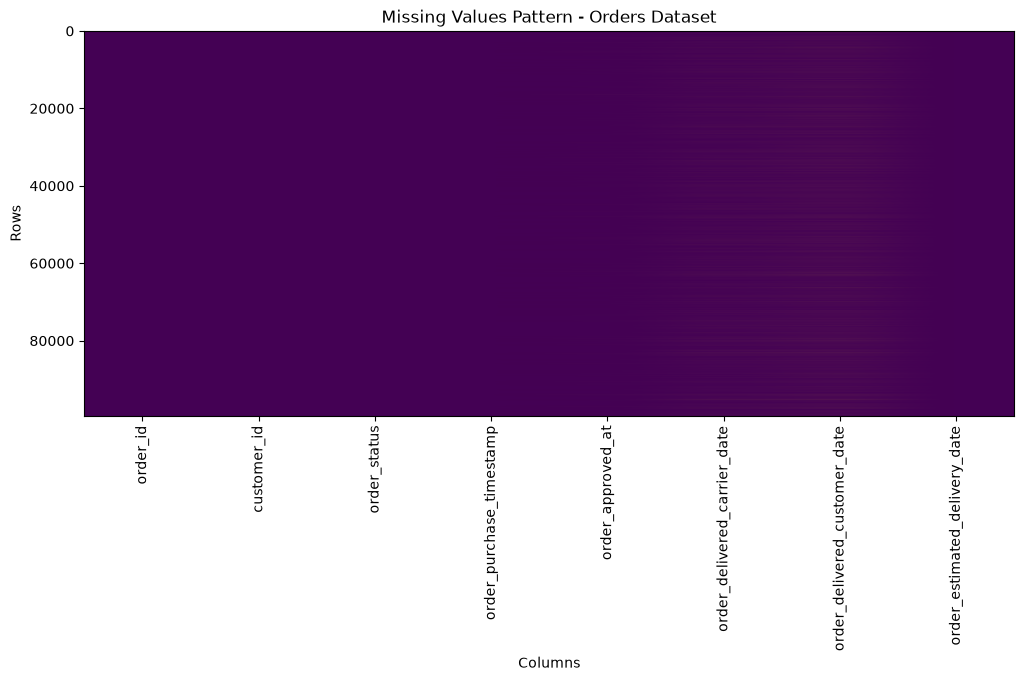

In [32]:
plt.figure(figsize=(12,5))

plt.imshow(
    datasets["orders"].isna(),
    aspect="auto"
)

plt.title("Missing Values Pattern - Orders Dataset")

plt.xlabel("Columns")

plt.ylabel("Rows")

plt.xticks(
    range(len(datasets["orders"].columns)),
    datasets["orders"].columns,
    rotation=90
)

plt.show()

# Domain Context

In [33]:
orders = datasets["orders"].copy()

orders["missing_delivery"] = (
    orders["order_delivered_customer_date"]
    .isna()
)

In [34]:
delivery_status = (

    orders

    .groupby("order_status")["missing_delivery"]

    .agg(
        Total_Orders="count",
        Missing_Delivery="sum"
    )

)

delivery_status["Missing (%)"] = (
    delivery_status["Missing_Delivery"]
    /
    delivery_status["Total_Orders"]
    *100
).round(2)

delivery_status

,Total_Orders,Missing_Delivery,Missing (%)
order_status,,,
approved,2,2,100.00
canceled,625,619,99.04
created,5,5,100.00
delivered,96478,8,0.01
invoiced,314,314,100.00
processing,301,301,100.00
shipped,1107,1107,100.00
unavailable,609,609,100.00


In [35]:
pd.crosstab(

    orders["order_status"],

    orders["missing_delivery"],

    margins=True

)

missing_delivery,False,True,All
order_status,,,
approved,0,2,2
canceled,6,619,625
created,0,5,5
delivered,96470,8,96478
invoiced,0,314,314
processing,0,301,301
shipped,0,1107,1107
unavailable,0,609,609
All,96476,2965,99441


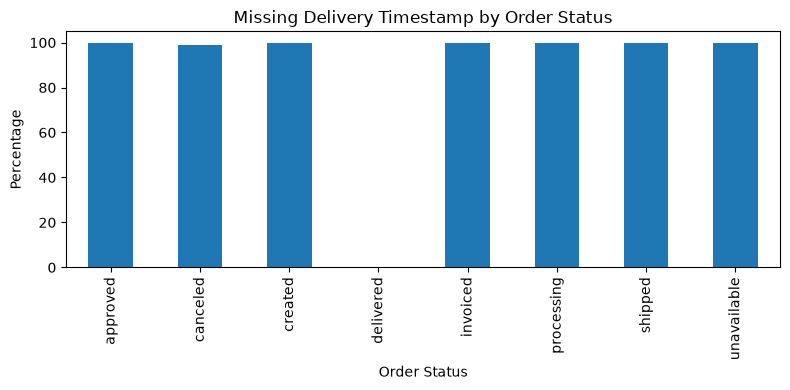

In [36]:
delivery_status["Missing (%)"].plot(
    kind="bar",
    figsize=(8,4)
)

plt.ylabel("Percentage")

plt.xlabel("Order Status")

plt.title("Missing Delivery Timestamp by Order Status")

plt.tight_layout()

plt.show()

In [37]:
invalid_delivered = orders[

    (orders["order_status"]=="delivered")

    &

    (orders["order_delivered_customer_date"].isna())

]

print(
    f"Invalid delivered orders: {len(invalid_delivered)}"
)

Invalid delivered orders: 8


In [38]:
cancelled = orders[

    orders["order_status"]=="canceled"

]

cancelled[
    [
        "order_status",
        "order_delivered_customer_date"
    ]
].head()

,order_status,order_delivered_customer_date
397,canceled,NaN
613,canceled,NaN
1058,canceled,NaN
1130,canceled,NaN
1801,canceled,NaN


# Validates numerical attributes

In [39]:
def audit_condition(df, table_name, column_name, condition, description):
    invalid = df.loc[condition(df[column_name])]

    return {
        "Table": table_name,
        "Column": column_name,
        "Rule": description,
        "Invalid Rows": len(invalid),
        "Passed": len(invalid) == 0
    }

In [40]:
numeric_audits = []

numeric_audits.append(
    audit_condition(
        datasets["order_items"],
        "order_items",
        "price",
        lambda x: x <= 0,
        "price > 0"
    )
)

numeric_audits.append(
    audit_condition(
        datasets["order_items"],
        "order_items",
        "freight_value",
        lambda x: x < 0,
        "freight_value >= 0"
    )
)

numeric_audits.append(
    audit_condition(
        datasets["order_payments"],
        "order_payments",
        "payment_value",
        lambda x: x <= 0,
        "payment_value > 0"
    )
)

numeric_audits.append(
    audit_condition(
        datasets["order_payments"],
        "order_payments",
        "payment_installments",
        lambda x: x < 1,
        "payment_installments >= 1"
    )
)

numeric_audits.append(
    audit_condition(
        datasets["order_reviews"],
        "order_reviews",
        "review_score",
        lambda x: ~x.between(1, 5),
        "review_score between 1 and 5"
    )
)

numeric_audits.append(
    audit_condition(
        datasets["products"],
        "products",
        "product_weight_g",
        lambda x: x <= 0,
        "product_weight_g > 0"
    )
)

numeric_audits = pd.DataFrame(numeric_audits)

numeric_audits

,Table,Column,Rule,Invalid Rows,Passed
0,order_items,price,price > 0,0,True
1,order_items,freight_value,freight_value >= 0,0,True
2,order_payments,payment_value,payment_value > 0,9,False
3,order_payments,payment_installments,payment_installments >= 1,2,False
4,order_reviews,review_score,review_score between 1 and 5,0,True
5,products,product_weight_g,product_weight_g > 0,4,False


In [41]:
customers = datasets["customers"].copy()
sellers = datasets["sellers"].copy()

customers["customer_zip_code_prefix"] = (
    customers["customer_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)

sellers["seller_zip_code_prefix"] = (
    sellers["seller_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)

In [42]:
zip_results = pd.DataFrame([
    {
        "Table": "customers",
        "Invalid ZIP Codes":
            (~customers["customer_zip_code_prefix"]
             .str.fullmatch(r"\d{5}")).sum()
    },
    {
        "Table": "sellers",
        "Invalid ZIP Codes":
            (~sellers["seller_zip_code_prefix"]
             .str.fullmatch(r"\d{5}")).sum()
    }
])

zip_results

,Table,Invalid ZIP Codes
0,customers,0
1,sellers,0


In [43]:
boundary_summary = pd.concat(
    [
        numeric_audits,
        zip_results.rename(
            columns={
                "Invalid ZIP Codes": "Invalid Rows"
            }
        ).assign(
            Column="zip_code_prefix",
            Rule="Must contain exactly 5 digits",
            Passed=lambda df: df["Invalid Rows"] == 0
        )
    ],
    ignore_index=True
)

boundary_summary

,Table,Column,Rule,Invalid Rows,Passed
0,order_items,price,price > 0,0,True
1,order_items,freight_value,freight_value >= 0,0,True
2,order_payments,payment_value,payment_value > 0,9,False
3,order_payments,payment_installments,payment_installments >= 1,2,False
4,order_reviews,review_score,review_score between 1 and 5,0,True
5,products,product_weight_g,product_weight_g > 0,4,False
6,customers,zip_code_prefix,Must contain exactly 5 digits,0,True
7,sellers,zip_code_prefix,Must contain exactly 5 digits,0,True


# Checking chronological order events

In [44]:
orders = datasets["orders"].copy()

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

In [45]:
purchase_approval = orders[
    (
        orders["order_approved_at"].notna()
    )
    &
    (
        orders["order_approved_at"]
        <
        orders["order_purchase_timestamp"]
    )
]

len(purchase_approval)

0

In [46]:
approval_carrier = orders[
    (
        orders["order_delivered_carrier_date"].notna()
    )
    &
    (
        orders["order_delivered_carrier_date"]
        <
        orders["order_approved_at"]
    )
]

len(approval_carrier)

1359

In [47]:
carrier_customer = orders[
    (
        orders["order_delivered_customer_date"].notna()
    )
    &
    (
        orders["order_delivered_customer_date"]
        <
        orders["order_delivered_carrier_date"]
    )
]

len(carrier_customer)

23

In [48]:
timeline_audit = pd.DataFrame([
    {
        "Validation": "Purchase → Approval",
        "Violations": len(purchase_approval)
    },
    {
        "Validation": "Approval → Carrier",
        "Violations": len(approval_carrier)
    },
    {
        "Validation": "Carrier → Customer",
        "Violations": len(carrier_customer)
    }
])

timeline_audit

,Validation,Violations
0,Purchase → Approval,0
1,Approval → Carrier,1359
2,Carrier → Customer,23


In [49]:
purchase_approval.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [50]:
approval_carrier.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04
64,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15
199,58d4c4747ee059eeeb865b349b41f53a,1755fad7863475346bc6c3773fe055d3,delivered,2018-07-21 12:49:32,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19,2018-07-31
210,412fccb2b44a99b36714bca3fef8ad7b,c6865c523687cb3f235aa599afef1710,delivered,2018-07-22 22:30:05,2018-07-23 12:31:53,2018-07-23 12:24:00,2018-07-24 19:26:42,2018-07-31
415,56a4ac10a4a8f2ba7693523bb439eede,78438ba6ace7d2cb023dbbc81b083562,delivered,2018-07-22 13:04:47,2018-07-27 23:31:09,2018-07-24 14:03:00,2018-07-28 00:05:39,2018-08-06


In [51]:
carrier_customer.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31


In [52]:
order_totals = (
    datasets["order_items"]
    .assign(
        total=lambda df: df["price"] + df["freight_value"]
    )
    .groupby("order_id", as_index=False)
    .agg(order_total=("total", "sum"))
)

order_totals.head()

,order_id,order_total
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [53]:
payment_totals = (
    datasets["order_payments"]
    .groupby("order_id", as_index=False)
    .agg(payment_total=("payment_value", "sum"))
)

payment_totals.head()

,order_id,payment_total
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [54]:
payment_audit = (
    order_totals
    .merge(
        payment_totals,
        on="order_id",
        how="outer"
    )
)

payment_audit["difference"] = (
    payment_audit["payment_total"]
    -
    payment_audit["order_total"]
).round(2)

payment_audit.head()

,order_id,order_total,payment_total,difference
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,72.19,0.0
1,00018f77f2f0320c557190d7a144bdd3,259.83,259.83,0.0
2,000229ec398224ef6ca0657da4fc703e,216.87,216.87,0.0
3,00024acbcdf0a6daa1e931b038114c75,25.78,25.78,0.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,218.04,-0.0


In [55]:
payment_mismatches = payment_audit[
    payment_audit["difference"].abs() > 0.01
]

payment_mismatches.head()

,order_id,order_total,payment_total,difference
166,00789ce015e7e5791c7914f32bb4fad4,168.83,190.81,21.98
533,016726239765c18f66826453f39c64e3,235.13,265.77,30.64
733,01e51b7c3025655646143d09b911e1d7,33.10,35.02,1.92
974,028aa7c930356788f861ed1b7f984819,57.53,62.94,5.41
1135,02f4dd90ba0feb8ec394cac05862d2b5,130.96,141.65,10.69


In [56]:
payment_summary = pd.DataFrame([
    {
        "Orders Checked": len(payment_audit),
        "Mismatches": len(payment_mismatches),
        "Match Rate (%)": round(
            (
                1
                -
                len(payment_mismatches)
                /
                len(payment_audit)
            ) * 100,
            2
        )
    }
])

payment_summary

,Orders Checked,Mismatches,Match Rate (%)
0,99441,303,99.7


In [57]:
payment_mismatches.sort_values(
    "difference",
    key=abs,
    ascending=False
).head(20)

,order_id,order_total,payment_total,difference
80176,ce6d150fb29ada17d2082f4847107665,1403.66,1586.47,182.81
42865,6e5fe7366a2e1bfbf3257dba0af1267f,287.91,406.92,119.01
43791,70b742795bc441e94a44a084b6d9ce7a,466.93,578.82,111.89
59228,996c7e73600ad3723e8627ab7bef81e4,587.90,664.43,76.53
43794,70b7e94ea46d3e8b5bc12a50186edaf0,213.15,274.84,61.69
73090,bc2c82b0ef78d2252b6176d1972db7c9,242.01,303.02,61.01
68015,af9ffff2ce6b3defd34fd4c78857a379,413.17,466.97,53.80
14745,262118ce178bb3e4590a3adcf6d62e6b,177.74,126.12,-51.62
74503,bfdb5bbb06458d600a33d61f5f287472,348.93,394.36,45.43
54744,8d9c0dc8d5a2ce804f6b925d8f8e6c1d,254.45,293.89,39.44


# Quality Visualizations

In [58]:
delivery = orders.copy()

delivery["delivery_days"] = (
    delivery["order_delivered_customer_date"]
    -
    delivery["order_purchase_timestamp"]
).dt.days

In [59]:
delivery = delivery[
    delivery["delivery_days"].notna()
]

delivery = delivery[
    delivery["delivery_days"] >= 0
]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9472\244843461.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


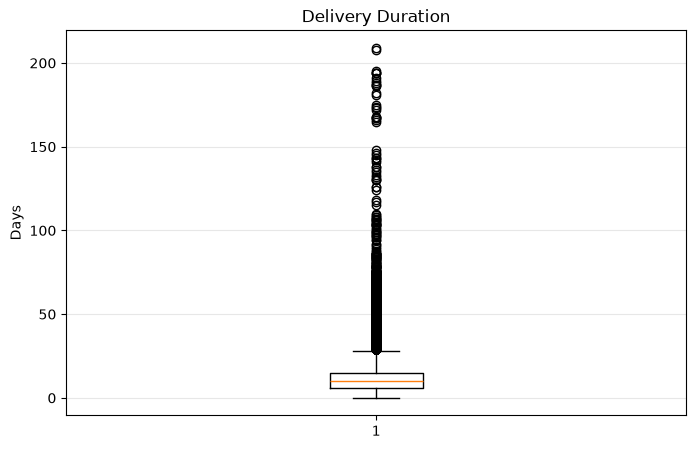

In [60]:
plt.figure(figsize=(8,5))

plt.boxplot(
    delivery["delivery_days"],
    vert=True
)

plt.title("Delivery Duration")

plt.ylabel("Days")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [61]:
payment_counts = (
    datasets["order_payments"]["payment_type"]
    .value_counts()
    .sort_values(ascending=False)
)

payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

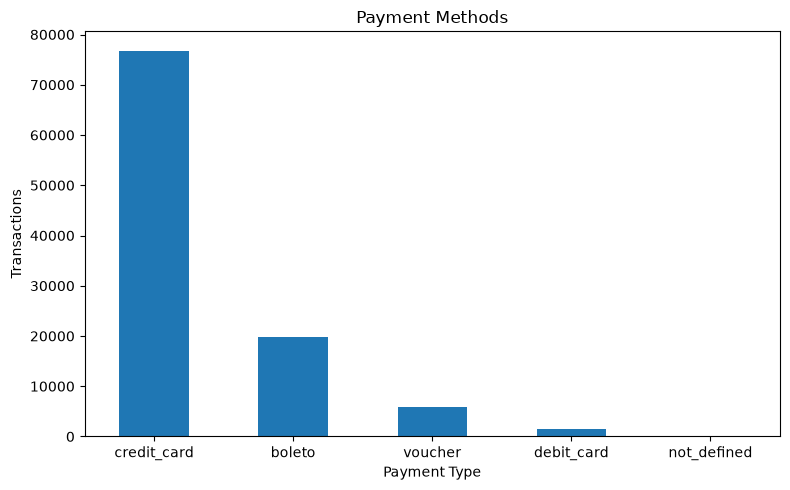

In [62]:
plt.figure(figsize=(8,5))

payment_counts.plot(kind="bar")

plt.title("Payment Methods")

plt.xlabel("Payment Type")

plt.ylabel("Transactions")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [63]:
orders_month = orders.copy()

orders_month["month"] = (
    orders_month["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [64]:
monthly_orders = (
    orders_month
    .groupby("month")
    .size()
)

monthly_orders.head()

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
dtype: int64

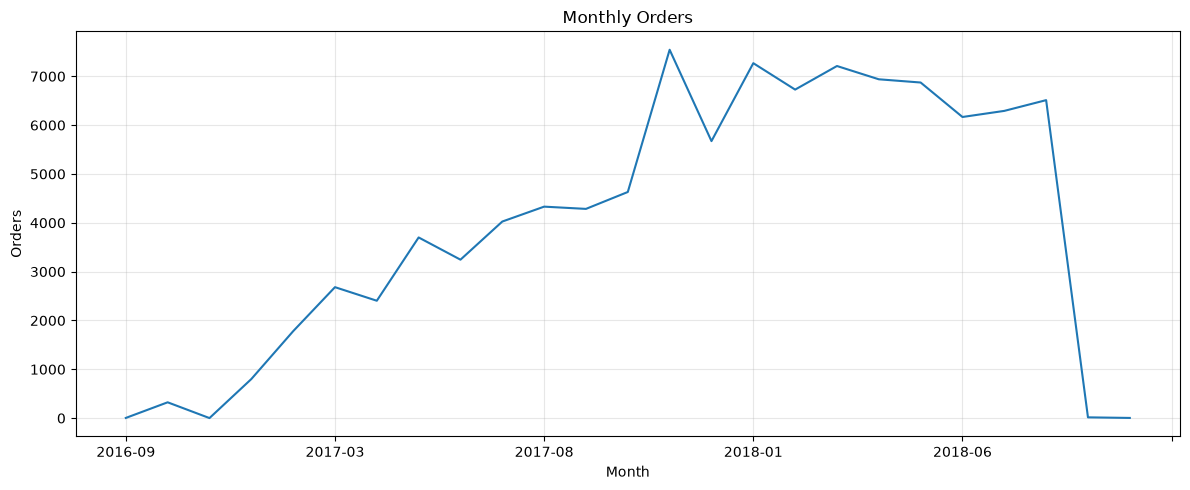

In [65]:
plt.figure(figsize=(12,5))

monthly_orders.plot()

plt.title("Monthly Orders")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()